In [132]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
# Loading the datasets
df_users=pd.read_csv("users.csv")
df_transactions=pd.read_csv("transactions.csv")
df_currency_details=pd.read_csv("currency_details.csv")
df_countries=pd.read_csv("countries.csv")

# Users data

In [4]:
df_users.head(2)

,ID,HAS_EMAIL,PHONE_COUNTRY,IS_FRAUDSTER,TERMS_VERSION,CREATED_DATE,STATE,COUNTRY,BIRTH_YEAR,KYC,FAILED_SIGN_IN_ATTEMPTS
0,1872820f-e3ac-4c02-bdc7-727897b60043,1,GB||JE||IM||GG,False,2018-05-25,2017-08-06 07:33:33.341000,ACTIVE,GB,1971,PASSED,0
1,545ff94d-66f8-4bea-b398-84425fb2301e,1,GB||JE||IM||GG,False,2018-01-01,2017-03-07 10:18:59.427000,ACTIVE,GB,1982,PASSED,0


In [5]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9944 entries, 0 to 9943
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       9944 non-null   object
 1   HAS_EMAIL                9944 non-null   int64 
 2   PHONE_COUNTRY            9944 non-null   object
 3   IS_FRAUDSTER             9944 non-null   bool  
 4   TERMS_VERSION            8417 non-null   object
 5   CREATED_DATE             9944 non-null   object
 6   STATE                    9944 non-null   object
 7   COUNTRY                  9944 non-null   object
 8   BIRTH_YEAR               9944 non-null   int64 
 9   KYC                      9944 non-null   object
 10  FAILED_SIGN_IN_ATTEMPTS  9944 non-null   int64 
dtypes: bool(1), int64(3), object(7)
memory usage: 786.7+ KB


In [6]:
df_users.describe()

,HAS_EMAIL,BIRTH_YEAR,FAILED_SIGN_IN_ATTEMPTS
count,9944.000000,9944.000000,9944.000000
mean,0.946702,1983.553298,0.008045
std,0.224639,11.350379,0.129737
min,0.000000,1927.000000,0.000000
25%,1.000000,1978.000000,0.000000
50%,1.000000,1986.000000,0.000000
75%,1.000000,1992.000000,0.000000
max,1.000000,2000.000000,6.000000


<Axes: ylabel='BIRTH_YEAR'>

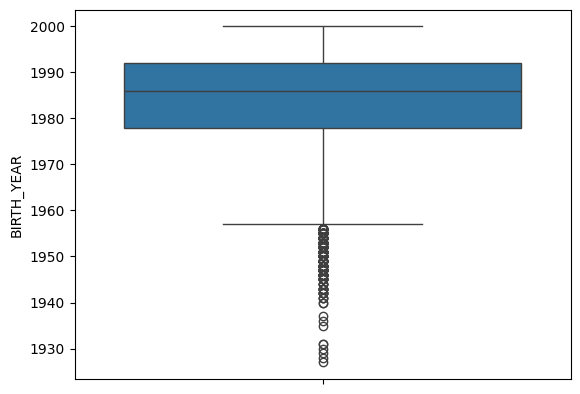

In [7]:
sns.boxplot(y=df_users['BIRTH_YEAR'])

**Insight:**
- No null values in users data
- Most of the users are born in the year 1985 approximately and in teh range of year 1975 and 1990.

# Transactions data

In [10]:
df_transactions.head(2)

,CURRENCY,AMOUNT,STATE,CREATED_DATE,MERCHANT_CATEGORY,MERCHANT_COUNTRY,ENTRY_METHOD,USER_ID,TYPE,SOURCE,ID,AMOUNT_USD
0,GBP,4420,COMPLETED,2017-12-10 16:38:55.577,NaN,NLD,chip,3ff52b92-d416-4e22-8cad-018f500d4bbc,ATM,GAIA,367bf5f9-7cce-4683-90b9-d3c011bf4c87,3268.0
1,PLN,1500,COMPLETED,2017-12-10 16:37:24.792,point_of_interest,POL,manu,76cbaad3-4721-4a3b-92b9-3eb9e9319565,CARD_PAYMENT,GAIA,ff6802b9-360d-4efe-b09b-f99c6cac3383,NaN


In [11]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688651 entries, 0 to 688650
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CURRENCY           688651 non-null  object 
 1   AMOUNT             688651 non-null  int64  
 2   STATE              688651 non-null  object 
 3   CREATED_DATE       688651 non-null  object 
 4   MERCHANT_CATEGORY  223065 non-null  object 
 5   MERCHANT_COUNTRY   483055 non-null  object 
 6   ENTRY_METHOD       688651 non-null  object 
 7   USER_ID            688651 non-null  object 
 8   TYPE               688651 non-null  object 
 9   SOURCE             688651 non-null  object 
 10  ID                 688651 non-null  object 
 11  AMOUNT_USD         635328 non-null  float64
dtypes: float64(1), int64(1), object(10)
memory usage: 63.0+ MB


In [12]:
df_transactions.describe()

,AMOUNT,AMOUNT_USD
count,6.886510e+05,6.353280e+05
mean,3.172575e+04,6.856953e+03
std,2.304381e+06,7.441684e+04
min,0.000000e+00,0.000000e+00
25%,4.800000e+02,3.590000e+02
50%,1.420000e+03,1.037000e+03
75%,5.000000e+03,3.713000e+03
max,9.000000e+08,1.641211e+07


<Axes: ylabel='AMOUNT'>

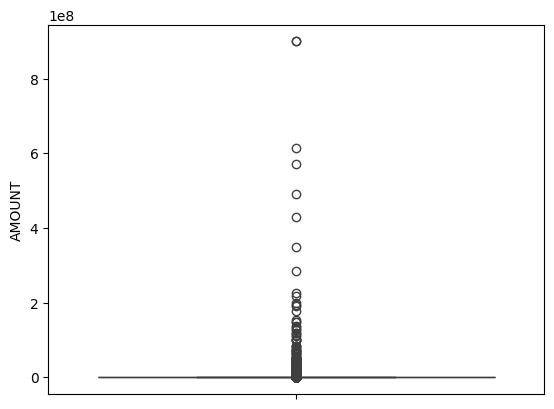

In [13]:
sns.boxplot(df_transactions['AMOUNT'])

**Insight:**
- columns 'MERCHANT_CATEGORY' and 'MERCHANT_COUNTRY' has most of the null values as compared to the column 'AMOUNT_USD'
- There are outliers in teh column 'AMOUNT'

# Currency_details data

In [16]:
df_currency_details.head(2)

,CCY,EXPONENT,IS_CRYPTO
0,AED,2,False
1,AFN,2,False


In [17]:
df_currency_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CCY        184 non-null    object
 1   EXPONENT   184 non-null    int64 
 2   IS_CRYPTO  184 non-null    bool  
dtypes: bool(1), int64(1), object(1)
memory usage: 3.2+ KB


In [18]:
df_currency_details.describe()

,EXPONENT
count,184.000000
mean,1.961957
std,1.189052
min,0.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,8.000000


<Axes: ylabel='EXPONENT'>

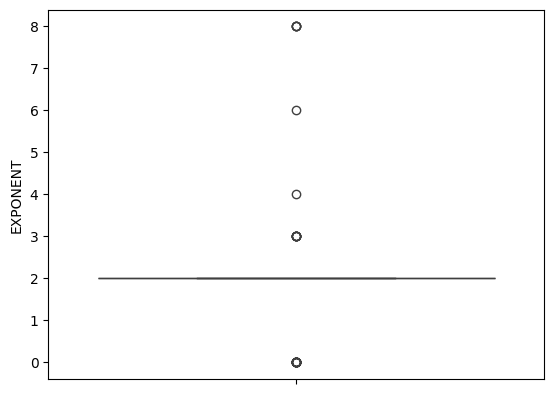

In [19]:
sns.boxplot(df_currency_details['EXPONENT'])

**Insights:**
- No null values in this dataset

# Countries data

In [22]:
df_countries.head(2)

,CODE,NAME,CODE3,NUMCODE,PHONECODE
0,AF,Afghanistan,AFG,4,93
1,AL,Albania,ALB,8,355


In [23]:
df_countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CODE       225 non-null    object
 1   NAME       226 non-null    object
 2   CODE3      226 non-null    object
 3   NUMCODE    226 non-null    int64 
 4   PHONECODE  226 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 9.0+ KB


In [24]:
df_countries.describe()

,NUMCODE,PHONECODE
count,226.000000,226.000000
mean,433.628319,531.371681
std,251.971451,648.237826
min,4.000000,0.000000
25%,219.000000,220.250000
50%,432.000000,354.500000
75%,645.250000,686.750000
max,894.000000,7370.000000


**Insights:**
- Only 1 null value in the country dataset

# Analyzing fraudsters

In [27]:
fraudster_count = len(df_users[df_users['IS_FRAUDSTER'] == True])
print('fraudster_count:', fraudster_count)

Total_users = len(df_users['IS_FRAUDSTER'])
print('Total_users:', Total_users)

fraudster_count: 298
Total_users: 9944


In [28]:
df_users['IS_FRAUDSTER'].value_counts(normalize=True)

IS_FRAUDSTER
False    0.970032
True     0.029968
Name: proportion, dtype: float64

Approximately 2.9% of users are detected as fraudsters amongst all users. that is 298 users out of 9944 users.

In [30]:
# Fraudsters count from each country

fraudster_country = df_users[df_users['IS_FRAUDSTER'] == True].groupby('COUNTRY').size().reset_index(name='fraudster_count').sort_values(by='fraudster_count', ascending=False)
fraudster_country

,COUNTRY,fraudster_count
5,GB,268
6,LT,14
9,RO,4
3,ES,3
4,FR,3
8,PL,2
0,BE,1
1,CZ,1
2,DE,1
7,NL,1


Country code GB stands for United Kingdom, which has maximum number of fraudsters.

In [32]:
# Checking if fraudsters have their KYC passed

KYC_check = df_users[df_users['IS_FRAUDSTER']==True] ['KYC'].value_counts().reset_index(name='fraudsters_count')
KYC_check

,KYC,fraudsters_count
0,PASSED,259
1,FAILED,22
2,PENDING,16
3,NONE,1


Out of all 298 frausters, 259 have their KYC passed. Therefore, KYC cannot be decided as a sole parameter for determing fraudsters.

In [34]:
# Age of fraudsters

fraudsters_birthyear = df_users[df_users['IS_FRAUDSTER']== True].groupby('BIRTH_YEAR').size().reset_index(name='count').sort_values(by='count', ascending=False).head()
fraudsters_birthyear

,BIRTH_YEAR,count
30,1988,26
33,1991,22
31,1989,18
29,1987,18
32,1990,17


Most of the fraudsters have their Birth year as 1988 and the fraudsters are in the birth year range of 1987 and 1991

In [36]:
# Fraudsters have email or not

df_users[df_users['IS_FRAUDSTER']==True]['HAS_EMAIL'].value_counts().reset_index(name='fraudsters_count')

,HAS_EMAIL,fraudsters_count
0,1,297
1,0,1


Almost all fraudsters have emails.

In [38]:
#  Fraudster failed sign-ins

df_users[df_users['IS_FRAUDSTER'] == True]['FAILED_SIGN_IN_ATTEMPTS'].value_counts().reset_index(name='fraudsters_count')

,FAILED_SIGN_IN_ATTEMPTS,fraudsters_count
0,0,295
1,2,2
2,1,1


Amlost all fraudsters have 0 failed sign-ins. So, this alone cannot be deciding factor for checking fraudsters.

**Merging users table and transactions table**

In [41]:
# we will merge users table in transactions table as transactions table has 688651 rows and users table has 9944 rows so as to prevent data loss.

tx_users_df = pd.merge(left=df_transactions,right=df_users,how='inner',left_on='USER_ID',right_on='ID',indicator=True)
tx_users_df.head()

,CURRENCY,AMOUNT,STATE_x,CREATED_DATE_x,MERCHANT_CATEGORY,MERCHANT_COUNTRY,ENTRY_METHOD,USER_ID,TYPE,SOURCE,ID_x,AMOUNT_USD,ID_y,HAS_EMAIL,PHONE_COUNTRY,IS_FRAUDSTER,TERMS_VERSION,CREATED_DATE_y,STATE_y,COUNTRY,BIRTH_YEAR,KYC,FAILED_SIGN_IN_ATTEMPTS,_merge
0,GBP,4420,COMPLETED,2017-12-10 16:38:55.577,NaN,NLD,chip,3ff52b92-d416-4e22-8cad-018f500d4bbc,ATM,GAIA,367bf5f9-7cce-4683-90b9-d3c011bf4c87,3268.0,3ff52b92-d416-4e22-8cad-018f500d4bbc,1,GB||JE||IM||GG,False,2018-03-20,2017-10-08 12:50:12.794000,ACTIVE,GB,1985,PASSED,0,both
1,PLN,1500,COMPLETED,2017-12-10 16:37:24.792,point_of_interest,POL,manu,76cbaad3-4721-4a3b-92b9-3eb9e9319565,CARD_PAYMENT,GAIA,ff6802b9-360d-4efe-b09b-f99c6cac3383,NaN,76cbaad3-4721-4a3b-92b9-3eb9e9319565,1,PL,False,2018-03-20,2017-11-16 17:38:12.378000,ACTIVE,PL,1976,PASSED,0,both
2,GBP,10000,COMPLETED,2017-12-10 16:34:42.592,NaN,NaN,misc,b3a6762b-a940-4459-bb1d-8e28e151f901,TOPUP,HERA,080ef0be-850a-4f14-ab03-28ff68e6b797,7394.0,b3a6762b-a940-4459-bb1d-8e28e151f901,1,GB||JE||IM||GG,False,2018-01-01,2017-07-10 11:50:36.688000,ACTIVE,GB,1992,PASSED,0,both
3,EUR,1159,COMPLETED,2017-12-10 16:34:17.88,NaN,FRA,manu,f5723f5e-5a00-4851-ae1d-5c11146aa491,CARD_PAYMENT,GAIA,bd13abac-4004-4c67-9bb7-90a42b027e82,977.0,f5723f5e-5a00-4851-ae1d-5c11146aa491,1,FR,False,2018-09-20,2016-07-28 00:26:52.447000,ACTIVE,FR,1990,PASSED,0,both
4,EUR,680,COMPLETED,2017-12-10 16:51:10.791,restaurant,DEU,chip,3c1aa14d-818a-474f-847f-3d24907dd1c7,CARD_PAYMENT,GAIA,99be2b3c-84d7-4522-96b3-8d834e67132f,573.0,3c1aa14d-818a-474f-847f-3d24907dd1c7,1,HU,False,2018-09-20,2017-05-31 06:48:35.014000,ACTIVE,HU,1978,PASSED,0,both


In [42]:
tx_users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638742 entries, 0 to 638741
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   CURRENCY                 638742 non-null  object  
 1   AMOUNT                   638742 non-null  int64   
 2   STATE_x                  638742 non-null  object  
 3   CREATED_DATE_x           638742 non-null  object  
 4   MERCHANT_CATEGORY        208677 non-null  object  
 5   MERCHANT_COUNTRY         447017 non-null  object  
 6   ENTRY_METHOD             638742 non-null  object  
 7   USER_ID                  638742 non-null  object  
 8   TYPE                     638742 non-null  object  
 9   SOURCE                   638742 non-null  object  
 10  ID_x                     638742 non-null  object  
 11  AMOUNT_USD               586125 non-null  float64 
 12  ID_y                     638742 non-null  object  
 13  HAS_EMAIL                638742 non-null  in

In [43]:
tx_users_df['AMOUNT']=tx_users_df['AMOUNT'].astype(int)

In [44]:
# Handling skewness in AMOUNT & AMOUNT_USD column

tx_users_df["AMOUNT_USD"] = np.log1p(tx_users_df["AMOUNT_USD"])
tx_users_df["AMOUNT"] = np.log1p(tx_users_df["AMOUNT"])

In [45]:
# tx_users_df[tx_users_df.select_dtypes(include="number").columns]=np.log1p(tx_users_df.select_dtypes(include="number"))

In [46]:
tx_users_df.describe()

,AMOUNT,AMOUNT_USD,HAS_EMAIL,BIRTH_YEAR,FAILED_SIGN_IN_ATTEMPTS
count,638742.000000,586125.000000,638742.000000,638742.000000,638742.000000
mean,7.233658,6.906672,0.989255,1984.940629,0.009552
std,2.102065,2.023692,0.103098,9.887922,0.141177
min,0.000000,0.000000,0.000000,1927.000000,0.000000
25%,6.148468,5.852202,1.000000,1980.000000,0.000000
50%,7.239933,6.916715,1.000000,1987.000000,0.000000
75%,8.517393,8.213382,1.000000,1992.000000,0.000000
max,20.617905,16.613530,1.000000,2000.000000,6.000000


In [47]:
len(tx_users_df[tx_users_df['IS_FRAUDSTER']==True])

13914

In [48]:
fraudsters_channel=tx_users_df[tx_users_df['IS_FRAUDSTER']==True]['TYPE'].value_counts()
fraudsters_channel

TYPE
CARD_PAYMENT     6393
TOPUP            3675
ATM              2188
BANK_TRANSFER    1222
P2P               436
Name: count, dtype: int64

<Axes: xlabel='TYPE'>

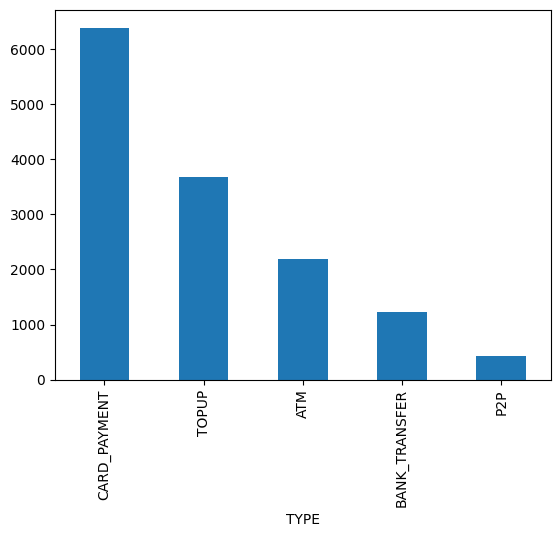

In [49]:
fraudsters_channel.plot(kind='bar')

From the above bar graph, we can tell that most of fraudsters use 'CARD_PAYMENT' as top channel for commiting fraud.

In [51]:
fraud_amount_relation=tx_users_df[tx_users_df['IS_FRAUDSTER']==True]['AMOUNT_USD'].value_counts().sort_values(ascending=False).head()
fraud_amount_relation

AMOUNT_USD
0.000000    513
4.317488    427
4.330733    265
4.304065    200
4.343805    127
Name: count, dtype: int64

In [52]:
entry_method_fraud = tx_users_df.groupby(['IS_FRAUDSTER','ENTRY_METHOD']).size().unstack(fill_value=0)
entry_method_fraud

ENTRY_METHOD,chip,cont,mags,manu,mcon,misc
IS_FRAUDSTER,,,,,,
False,165505,155884,21254,82886,490,198809
True,3102,1859,35,3365,2,5551


Fraudsters use 'manual' and 'miscellaneous' methods for fraud mostly.

In [54]:
# craeting column to check fraud time

tx_users_df["CREATED_DATE_x"] = pd.to_datetime(tx_users_df["CREATED_DATE_x"], format="mixed")
tx_users_df["hour"] = tx_users_df["CREATED_DATE_x"].dt.hour
tx_users_df["date"] = tx_users_df["CREATED_DATE_x"].dt.date
tx_users_df["is_weekend"] = (tx_users_df["CREATED_DATE_x"].dt.dayofweek >= 5).astype(int)
tx_users_df["is_night"] = ((tx_users_df["hour"] >= 0) & (tx_users_df["hour"] <= 5)).astype(int)

In [55]:
agg_df=tx_users_df.groupby('USER_ID')

In [56]:
aggregate_df = agg_df.agg(
    tx_count=("ID_x", "size"),             
    active_days=("date", "nunique"),
    avg_amount_usd=("AMOUNT_USD", "mean"),
    max_amount_usd=("AMOUNT_USD", "max"),
    total_amount_usd=("AMOUNT_USD", "sum"),
    weekend_avg_txn=("is_weekend", "mean"),
    night_avg_txn=("is_night", "mean"),
).reset_index()

In [57]:
aggregate_df.head(5)

,USER_ID,tx_count,active_days,avg_amount_usd,max_amount_usd,total_amount_usd,weekend_avg_txn,night_avg_txn
0,000e88bb-d302-4fdc-b757-2b1a2c33e7d6,16,6,5.301122,6.210600,15.903367,0.375000,0.000000
1,001032e0-8071-4baf-95b9-e50214665c2e,36,22,7.415715,10.180816,266.965725,0.027778,0.055556
2,00131af8-66f0-4526-8b5f-dc2fdb26c7d7,7,2,6.868034,8.047190,48.076238,0.000000,0.000000
3,001926be-3245-43fa-86dd-b40ee160b6f9,254,94,7.475727,10.982135,1898.834771,0.488189,0.003937
4,001cc034-5730-47c6-a70c-25f42249c9ee,4,2,7.663399,7.667626,15.326797,0.000000,0.250000


In [58]:
aggregate_df.isnull().sum()

USER_ID               0
tx_count              0
active_days           0
avg_amount_usd      562
max_amount_usd      562
total_amount_usd      0
weekend_avg_txn       0
night_avg_txn         0
dtype: int64

In [59]:
aggregate_df=aggregate_df.fillna(0)
aggregate_df.isnull().sum()

USER_ID             0
tx_count            0
active_days         0
avg_amount_usd      0
max_amount_usd      0
total_amount_usd    0
weekend_avg_txn     0
night_avg_txn       0
dtype: int64

In [60]:
txn_type_per_user_df=pd.crosstab(tx_users_df['USER_ID'], tx_users_df['TYPE'], normalize="index").add_suffix("_percentage")
txn_type_per_user_df.head()

TYPE,ATM_percentage,BANK_TRANSFER_percentage,CARD_PAYMENT_percentage,P2P_percentage,TOPUP_percentage
USER_ID,,,,,
000e88bb-d302-4fdc-b757-2b1a2c33e7d6,0.000000,0.0625,0.500000,0.125000,0.312500
001032e0-8071-4baf-95b9-e50214665c2e,0.055556,0.0000,0.638889,0.000000,0.305556
00131af8-66f0-4526-8b5f-dc2fdb26c7d7,0.000000,0.0000,0.428571,0.000000,0.571429
001926be-3245-43fa-86dd-b40ee160b6f9,0.078740,0.0000,0.629921,0.059055,0.232283
001cc034-5730-47c6-a70c-25f42249c9ee,0.000000,0.5000,0.000000,0.000000,0.500000


In [61]:
# ENTRY_METHOD per user
entry_type_pct_per_user = pd.crosstab(tx_users_df["USER_ID"],tx_users_df["ENTRY_METHOD"],normalize="index").add_suffix("_percentage")
entry_type_pct_per_user.head()

ENTRY_METHOD,chip_percentage,cont_percentage,mags_percentage,manu_percentage,mcon_percentage,misc_percentage
USER_ID,,,,,,
000e88bb-d302-4fdc-b757-2b1a2c33e7d6,0.000000,0.500000,0.000000,0.000000,0.0,0.500000
001032e0-8071-4baf-95b9-e50214665c2e,0.333333,0.166667,0.138889,0.055556,0.0,0.305556
00131af8-66f0-4526-8b5f-dc2fdb26c7d7,0.142857,0.000000,0.000000,0.285714,0.0,0.571429
001926be-3245-43fa-86dd-b40ee160b6f9,0.295276,0.228346,0.000000,0.185039,0.0,0.291339
001cc034-5730-47c6-a70c-25f42249c9ee,0.000000,0.000000,0.000000,0.000000,0.0,1.000000


In [62]:
user_df = tx_users_df[["USER_ID", "IS_FRAUDSTER", "HAS_EMAIL", "FAILED_SIGN_IN_ATTEMPTS", "KYC", "COUNTRY"]].drop_duplicates("USER_ID")

final_df = (
    user_df
      .merge(aggregate_df, on="USER_ID", how="left")
      .merge(txn_type_per_user_df, left_on="USER_ID", right_index=True, how="left")
      .merge(entry_type_pct_per_user, left_on="USER_ID", right_index=True, how="left")
      .fillna(0)
)

final_df.head()

,USER_ID,IS_FRAUDSTER,HAS_EMAIL,FAILED_SIGN_IN_ATTEMPTS,KYC,COUNTRY,tx_count,active_days,avg_amount_usd,max_amount_usd,total_amount_usd,weekend_avg_txn,night_avg_txn,ATM_percentage,BANK_TRANSFER_percentage,CARD_PAYMENT_percentage,P2P_percentage,TOPUP_percentage,chip_percentage,cont_percentage,mags_percentage,manu_percentage,mcon_percentage,misc_percentage
0,3ff52b92-d416-4e22-8cad-018f500d4bbc,False,1,0,PASSED,GB,62,36,7.713651,10.527151,478.246335,0.354839,0.032258,0.354839,0.016129,0.306452,0.000000,0.322581,0.483871,0.145161,0.000000,0.032258,0.0,0.338710
1,76cbaad3-4721-4a3b-92b9-3eb9e9319565,False,1,0,PASSED,PL,26,14,7.696667,7.696667,15.393334,0.115385,0.000000,0.038462,0.000000,0.576923,0.000000,0.384615,0.038462,0.115385,0.000000,0.461538,0.0,0.384615
2,b3a6762b-a940-4459-bb1d-8e28e151f901,False,1,0,PASSED,GB,330,120,7.343278,11.247109,2379.221990,0.215152,0.075758,0.133333,0.003030,0.648485,0.006061,0.209091,0.318182,0.266667,0.042424,0.115152,0.0,0.257576
3,f5723f5e-5a00-4851-ae1d-5c11146aa491,False,1,0,PASSED,FR,452,231,6.783548,11.300413,3066.163602,0.311947,0.046460,0.024336,0.019912,0.703540,0.057522,0.194690,0.181416,0.146018,0.000000,0.396018,0.0,0.276549
4,3c1aa14d-818a-474f-847f-3d24907dd1c7,False,1,0,PASSED,HU,119,58,8.861593,12.838952,877.297683,0.218487,0.058824,0.025210,0.084034,0.428571,0.042017,0.420168,0.201681,0.159664,0.000000,0.092437,0.0,0.546218


In [63]:
final_df.shape[0], final_df["USER_ID"].nunique()


(7748, 7748)

In [65]:
y = final_df["IS_FRAUDSTER"].astype(int)
X = final_df.drop(columns=["IS_FRAUDSTER", "USER_ID"])

Train → fit the model

Validation → choose threshold / compare models

Test → final, honest performance

In [67]:
X = pd.get_dummies(X, columns=["KYC", "COUNTRY"], dummy_na=True)

In [68]:
X_train,X_temp,y_train,y_temp=train_test_split(X,y, test_size=0.30, random_state=42, stratify=y)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp, test_size=0.30, random_state=42, stratify=y_temp)

In [69]:
# train
clf = LogisticRegression(max_iter=500, class_weight="balanced", solver="liblinear")
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


In [70]:
val_proba = clf.predict_proba(X_val)[:, 1]
test_proba = clf.predict_proba(X_test)[:, 1]

In [71]:
print("VAL  ROC-AUC:", roc_auc_score(y_val, val_proba))
print("VAL  PR-AUC :", average_precision_score(y_val, val_proba))

print("TEST ROC-AUC:", roc_auc_score(y_test, test_proba))
print("TEST PR-AUC :", average_precision_score(y_test, test_proba))

VAL  ROC-AUC: 0.9047201896320726
VAL  PR-AUC : 0.41112661364849645
TEST ROC-AUC: 0.9554562013578408
TEST PR-AUC : 0.6590733780660355


In [72]:
prec, rec, thr = precision_recall_curve(y_val, val_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.nanargmax(f1)
best_thr = thr[best_idx - 1] if best_idx > 0 else 0.5
print("Best threshold:", best_thr)

Best threshold: 0.9143092725340204


In [73]:
test_pred = (test_proba >= best_thr).astype(int)

print("Confusion matrix:\n", confusion_matrix(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred, zero_division=0))
print("F1       :", f1_score(y_test, test_pred, zero_division=0))

Confusion matrix:
 [[665   6]
 [ 15  12]]
Precision: 0.6666666666666666
Recall   : 0.4444444444444444
F1       : 0.5333333333333333


I trained a Logistic Regression classifier with class weights to handle the ~4% fraud class imbalance. 

- On the validation set, the model achieved ROC-AUC = 0.905 and PR-AUC = 0.410
- on the held-out test set, ROC-AUC improved to 0.956 and PR-AUC to 0.658. Because fraud is rare, I focused on PR-AUC and precision/recall rather than accuracy.
- Using a validation-tuned threshold of 0.915, the model achieved Precision = 0.667, Recall = 0.444, and F1 = 0.533 on the test set (TP=12, FP=6, FN=15).
- This indicates the model is strong at ranking fraud risk and can be operated conservatively to keep false positives low, at the cost of missing some fraud cases.

**Insights**

- If the business wants fewer false alarms, we keep a high threshold like 0.915 (high precision).
- If the business wants to catch more fraud, we lower the threshold to improve recall, accepting more false positives.”

This model is trained on users with transaction history (users without transactions are excluded due to the inner join